<a href="https://colab.research.google.com/github/jayden14141/Network-Anomaly-Detection/blob/main/ml/notebooks/05_ovr_small.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import json
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    df = pd.read_csv('/content/drive/MyDrive/cicids2017_cleaned.csv')
    with open('/content/drive/MyDrive/attack_features.json') as f:
        attack_features = json.load(f)
    with open('/content/drive/MyDrive/attack_groups.json') as f:
        groups = json.load(f)
    print(f"Loaded from Drive: {df.shape}")
except Exception as e:
    print(f"Drive mount failed: {e}")

Mounted at /content/drive
Loaded from Drive: (2827876, 79)


In [ ]:
LABEL_COL     = 'Label'
BENIGN_RATIO  = 5
TEST_SIZE     = 0.20
CV_SPLITS     = 3
RANDOM_STATE  = 42
AE_EPOCHS     = 10
AE_BATCH      = 256
AE_THRESHOLD_PERCENTILE = 95
MAX_ATTACK_SAMPLES = 50_000
OUTPUT_RESULTS = '/content/drive/MyDrive/results_small.json'

In [ ]:
small_attacks = groups['small']
print(f"Small attacks: {small_attacks}")
for a in small_attacks:
    print(f"  {a:<30s}: {(df[LABEL_COL] == a).sum():>5,}")

Small attacks: ['Web Attack - XSS', 'Infiltration', 'Web Attack - Sql Injection', 'Heartbleed']
  Web Attack - XSS              :   652
  Infiltration                  :    36
  Web Attack - Sql Injection    :    21
  Heartbleed                    :    11


In [ ]:
from sklearn.model_selection import train_test_split

def build_ovr_dataset(df, attack, features):
    attack_mask = df[LABEL_COL] == attack
    benign_mask = df[LABEL_COL] == 'BENIGN'

    rng = np.random.RandomState(RANDOM_STATE)

    attack_idx = df.index[attack_mask].to_numpy()
    if len(attack_idx) > MAX_ATTACK_SAMPLES:
        attack_idx = rng.choice(attack_idx, size=MAX_ATTACK_SAMPLES, replace=False)

    n_attack = len(attack_idx)

    # For very small attacks, ensure minimum BENIGN count for meaningful training
    n_benign_target = max(n_attack * BENIGN_RATIO, 100)
    benign_idx = df.index[benign_mask].to_numpy()
    if len(benign_idx) > n_benign_target:
        benign_idx = rng.choice(benign_idx, size=n_benign_target, replace=False)

    combined_idx = np.concatenate([benign_idx, attack_idx])
    subset = df.loc[combined_idx]
    X = subset[features].copy()
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)
    y = (subset[LABEL_COL] == attack).astype(int).values

    # For tiny classes (< 5 per split), reduce CV or skip stratify
    min_class = min(np.bincount(y))
    if min_class < CV_SPLITS:
        # Too few for stratified split — use simple split
        return train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    return train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )

In [ ]:
def train_rf(X_tr, y_tr):
    m = RandomForestClassifier(
        n_estimators=200, max_depth=15, class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE
    )
    m.fit(X_tr, y_tr)
    return m

def train_xgb(X_tr, y_tr):
    pos = (y_tr == 1).sum()
    neg = (y_tr == 0).sum()
    m = xgb.XGBClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.1,
        scale_pos_weight=neg / max(pos, 1),
        eval_metric='logloss', n_jobs=-1,
        random_state=RANDOM_STATE, verbosity=0
    )
    m.fit(X_tr, y_tr)
    return m

def train_lgb(X_tr, y_tr):
    m = lgb.LGBMClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.1,
        class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
    )
    m.fit(X_tr, y_tr)
    return m

def train_autoencoder(X_tr, y_tr):
    scaler = StandardScaler()
    X_benign = X_tr[y_tr == 0]
    X_scaled = scaler.fit_transform(X_benign)

    dim = X_scaled.shape[1]
    inp = layers.Input(shape=(dim,))
    enc = layers.Dense(dim // 2, activation='relu')(inp)
    enc = layers.Dense(max(dim // 4, 2), activation='relu')(enc)
    dec = layers.Dense(dim // 2, activation='relu')(enc)
    out = layers.Dense(dim, activation='linear')(dec)
    ae = Model(inp, out)
    ae.compile(optimizer='adam', loss='mse')
    ae.fit(X_scaled, X_scaled, epochs=AE_EPOCHS, batch_size=AE_BATCH, verbose=0)

    recon = ae.predict(X_scaled, verbose=0)
    errors = np.mean((X_scaled - recon) ** 2, axis=1)
    threshold = np.percentile(errors, AE_THRESHOLD_PERCENTILE)
    return {'model': ae, 'scaler': scaler, 'threshold': threshold}

def predict_autoencoder(ae_bundle, X):
    X_scaled = ae_bundle['scaler'].transform(X)
    recon = ae_bundle['model'].predict(X_scaled, verbose=0)
    errors = np.mean((X_scaled - recon) ** 2, axis=1)
    return (errors > ae_bundle['threshold']).astype(int)

In [ ]:
from sklearn.model_selection import StratifiedKFold

def evaluate(y_true, y_pred):
    return {
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
    }

MODELS = {
    'RF':       (train_rf,          lambda m, X: m.predict(X)),
    'XGBoost':  (train_xgb,         lambda m, X: m.predict(X)),
    'LightGBM': (train_lgb,         lambda m, X: m.predict(X)),
    'AE':       (train_autoencoder, predict_autoencoder),
}

results = {}

for attack in small_attacks:
    print(f"\n{'='*60}\n[{attack}]\n{'='*60}")
    feats = attack_features[attack]
    X_train, X_test, y_train, y_test = build_ovr_dataset(df, attack, feats)
    n_attack_train = (y_train == 1).sum()
    n_attack_test = (y_test == 1).sum()
    print(f"  Train: {len(X_train):,} (attack={n_attack_train})  Test: {len(X_test):,} (attack={n_attack_test})")

    results[attack] = {}

    # Adjust CV splits for tiny datasets
    min_class_train = min(np.bincount(y_train))
    n_splits = min(CV_SPLITS, min_class_train)
    if n_splits < 2:
        print(f"  ⚠ Too few attack samples for CV (n={n_attack_train}), skipping CV")

    for model_name, (train_fn, predict_fn) in MODELS.items():
        t0 = time.time()

        cv_scores = {'recall': [], 'precision': [], 'f1': []}
        if n_splits >= 2:
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
            for tr_idx, val_idx in skf.split(X_train, y_train):
                try:
                    m = train_fn(X_train.iloc[tr_idx], y_train[tr_idx])
                    preds = predict_fn(m, X_train.iloc[val_idx])
                    s = evaluate(y_train[val_idx], preds)
                    for k in cv_scores:
                        cv_scores[k].append(s[k])
                except Exception as e:
                    print(f"    CV fold failed ({model_name}): {e}")

        m_final = train_fn(X_train, y_train)
        y_pred_test = predict_fn(m_final, X_test)
        test = evaluate(y_test, y_pred_test)

        elapsed = time.time() - t0
        cv_recall_mean = float(np.mean(cv_scores['recall'])) if cv_scores['recall'] else None
        cv_recall_std = float(np.std(cv_scores['recall'])) if cv_scores['recall'] else None

        results[attack][model_name] = {
            'cv_recall_mean': cv_recall_mean,
            'cv_recall_std':  cv_recall_std,
            'cv_f1_mean':     float(np.mean(cv_scores['f1'])) if cv_scores['f1'] else None,
            'test_recall':    float(test['recall']),
            'test_precision': float(test['precision']),
            'test_f1':        float(test['f1']),
            'elapsed_sec':    round(elapsed, 1),
            'n_attack_train': int(n_attack_train),
            'n_attack_test':  int(n_attack_test),
        }
        cv_str = f"{cv_recall_mean:.3f}±{cv_recall_std:.3f}" if cv_recall_mean is not None else "N/A"
        print(f"  {model_name:<10s} "
              f"CV recall={cv_str}  "
              f"Test recall={test['recall']:.3f}  F1={test['f1']:.3f}  ({elapsed:.1f}s)")


[Web Attack - XSS]
  Train: 3,129 (attack=522)  Test: 783 (attack=130)
  RF         CV recall=0.971±0.014  Test recall=0.985  F1=0.992  (3.1s)
  XGBoost    CV recall=0.973±0.014  Test recall=0.985  F1=0.985  (1.2s)
  LightGBM   CV recall=0.975±0.010  Test recall=0.985  F1=0.988  (7.9s)
  AE         CV recall=0.029±0.008  Test recall=0.015  F1=0.023  (10.2s)

[Infiltration]
  Train: 172 (attack=29)  Test: 44 (attack=7)
  RF         CV recall=0.822±0.110  Test recall=1.000  F1=1.000  (3.1s)
  XGBoost    CV recall=0.893±0.091  Test recall=1.000  F1=1.000  (0.8s)
  LightGBM   CV recall=1.000±0.000  Test recall=1.000  F1=1.000  (0.6s)


  AE         CV recall=0.644±0.235  Test recall=0.857  F1=0.857  (13.5s)

[Web Attack - Sql Injection]
  Train: 100 (attack=17)  Test: 26 (attack=4)
  RF         CV recall=1.000±0.000  Test recall=1.000  F1=1.000  (2.2s)
  XGBoost    CV recall=1.000±0.000  Test recall=1.000  F1=1.000  (0.2s)
  LightGBM   CV recall=0.867±0.189  Test recall=1.000  F1=0.889  (0.4s)
  AE         CV recall=0.000±0.000  Test recall=0.000  F1=0.000  (13.4s)

[Heartbleed]
  Train: 88 (attack=9)  Test: 23 (attack=2)
  RF         CV recall=0.889±0.157  Test recall=1.000  F1=1.000  (1.9s)
  XGBoost    CV recall=0.889±0.157  Test recall=0.500  F1=0.667  (0.2s)
  LightGBM   CV recall=1.000±0.000  Test recall=1.000  F1=1.000  (0.1s)
  AE         CV recall=1.000±0.000  Test recall=1.000  F1=1.000  (9.9s)


In [ ]:
with open(OUTPUT_RESULTS, 'w') as f:
    json.dump(results, f, indent=2)
print(f"Saved: {OUTPUT_RESULTS}")

Saved: /content/drive/MyDrive/results_small.json


In [ ]:
rows = []
for attack, models in results.items():
    for model, s in models.items():
        cv_str = f"{s['cv_recall_mean']:.3f}±{s['cv_recall_std']:.3f}" if s['cv_recall_mean'] is not None else "N/A"
        rows.append({
            'Attack': attack,
            'Model': model,
            'n_train': s['n_attack_train'],
            'CV Recall': cv_str,
            'Test Recall': round(s['test_recall'], 3),
            'Test Precision': round(s['test_precision'], 3),
            'Test F1': round(s['test_f1'], 3),
            'Time(s)': s['elapsed_sec'],
        })
comp_df = pd.DataFrame(rows).sort_values(['Attack', 'Test Recall'], ascending=[True, False])
print(comp_df.to_string(index=False))

                    Attack    Model  n_train   CV Recall  Test Recall  Test Precision  Test F1  Time(s)
                Heartbleed       RF        9 0.889±0.157        1.000           1.000    1.000      1.9
                Heartbleed LightGBM        9 1.000±0.000        1.000           1.000    1.000      0.1
                Heartbleed       AE        9 1.000±0.000        1.000           1.000    1.000      9.9
                Heartbleed  XGBoost        9 0.889±0.157        0.500           1.000    0.667      0.2
              Infiltration       RF       29 0.822±0.110        1.000           1.000    1.000      3.1
              Infiltration  XGBoost       29 0.893±0.091        1.000           1.000    1.000      0.8
              Infiltration LightGBM       29 1.000±0.000        1.000           1.000    1.000      0.6
              Infiltration       AE       29 0.644±0.235        0.857           0.857    0.857     13.5
Web Attack - Sql Injection       RF       17 1.000±0.000        

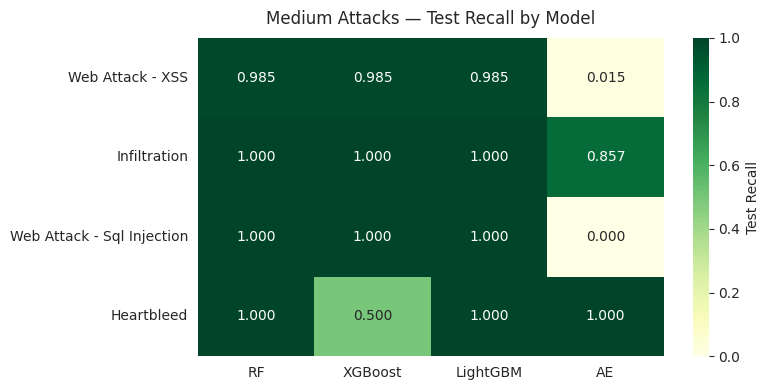

In [ ]:
heatmap_data = pd.DataFrame(
    {m: [results[a][m]['test_recall'] for a in small_attacks] for m in MODELS},
    index=small_attacks
)
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGn',
            vmin=0, vmax=1, cbar_kws={'label': 'Test Recall'}, ax=ax)
ax.set_title('Medium Attacks — Test Recall by Model', pad=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/results_small_recall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()